## Pulse-coupled fish: square-wave input and social escapes

Each fish combines leaky evidence accumulation, neighbour escape pulses,
and independent Gaussian noise:

$$\Delta x_i = \frac{\Delta t}{\tau}
\left[-x_i(t) + L_i(t) + S_i(t)\right]
+ \sigma\sqrt{\Delta t}\,\xi_{i,t}.$$

$$S_i(t) = w\frac{\sum_j A_{ij}c_j(t)}{\sum_j A_{ij}}.$$

Fish without neighbours receive zero social input.

Here, $x_i$ is `fish.evidence`, $L_i$ is the fish's external input, $\tau$ is
`tau_evidence`, and $w$ is `social_strength`. $A_{ij}$ is the connection weight
from fish $j$ to fish $i$, and $c_j$ is its remaining social cue. Each $\xi_{i,t}$ is an
independent standard normal draw, scaled by `noise_strength` and `np.sqrt(dt)`.
Time is in seconds. Each escape adds to a cue that fades with `tau_social`;
accumulated evidence relaxes with `tau_evidence`.

Sheltered and unsheltered fish use the same evidence update. Direct and social
inputs are added together in the drift, which pulls evidence toward their sum
with timescale `tau_evidence`. When both inputs are absent, evidence relaxes
toward zero. Both input contributions are scaled by `dt / tau_evidence`.
Gaussian noise is added separately and can move evidence up or down in either
state, including below zero.

State only determines which behavioral threshold applies. Reaching `threshold`
while unsheltered triggers escape and emits one spike. A sheltered fish recovers
strictly below `recovery_threshold`. Remaining sheltered emits no further spikes.

Only the first `n_exposed` fish receive the external stimulus directly. Every fish can receive
neighbour escape pulses. `random_seed` makes runs reproducible;
`noise_strength = 0` removes noise and `social_strength = 0` removes social input.
Reusable code lives in [agent.py](agent.py), [stimulus.py](stimulus.py),
and [network.py](network.py).

In [85]:
import numpy as np
import matplotlib.pyplot as plt

from agent import Agent
from stimulus import loom, square_wave
from network import all_to_all, ring, random_network

In [ ]:
## Group size, timing, and state thresholds
n_fish = 20
total_time = 1.0
dt = 0.001
tau_evidence = 0.1
threshold = 0.5
recovery_threshold = 0.1

In [87]:
## Evidence noise
noise_strength = 0.2
random_seed = 2026

## Social input amplitude and cue decay
social_strength = 5
tau_social = 0.03

## External stimulus
n_exposed = 5
stimulus_start = 0.2
stimulus_strength = 1.0
stimulus_duration = 0.3

The simulation uses exactly `n_steps` updates, indexed from `0` through
`n_steps - 1`. Times mark update starts; histories store results after each update.

In [88]:
n_steps = round(total_time / dt)
time = np.arange(n_steps) * dt

## Square-wave stimulus

The square pulse has amplitude `stimulus_strength`, begins at
`stimulus_start`, and lasts for `stimulus_duration` seconds. It includes
the start and excludes the end; outside that interval, input is zero.
Only the first `n_exposed` fish receive this input directly.

[stimulus.py](stimulus.py) provides both `square_wave` and `loom`, each
returning one input value per timestep. The cell below chooses `square_wave`.

A custom stimulus can replace `external_input` with another array of the same
length as `time`; the fish update loop uses that array directly.

In [89]:
external_input = square_wave(
    time, stimulus_strength, duration=stimulus_duration, start=stimulus_start,
)

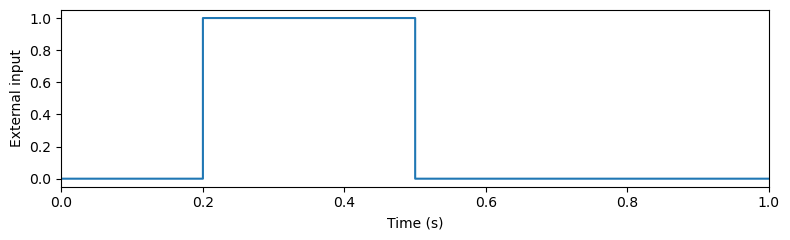

In [90]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.step(time, external_input, where="post")
ax.set(xlim=(0, total_time), xlabel="Time (s)", ylabel="External input")
fig.tight_layout()
plt.show()

## Initial positions

Each fish receives a fixed position `(x, y)`. Both coordinates are drawn
independently from a Gaussian with mean `position_mean` and standard
deviation `position_std`, in arbitrary spatial units. `positions` has one
row per fish; the agent stores that row as `fish.position`.

`position_seed` controls these draws independently of evidence noise.
The random network is generated independently of positions.

In [ ]:
position_mean = 0.0
position_std = 1.0
position_seed = 2026

In [ ]:
position_rng = np.random.default_rng(position_seed)
positions = position_rng.normal(
    position_mean, position_std, size=(n_fish, 2),
)

## Social interactions

[network.py](network.py) provides three editable adjacency matrices:

- `all_to_all(n_fish)` connects every pair.
- `ring(n_fish, neighbours_each_side)` connects neighbours on either side
  of each fish in a circular ordering.
- `random_network(n_fish, connection_probability, network_seed)` connects
  each pair independently with the chosen probability.

`adjacency[i, j]` is the weight of the connection from fish `j` to fish `i`.
All three networks have connections in both directions and a zero diagonal,
so a fish does not respond to its own escape. The default is `random_network`.
Choose a network by replacing the `adjacency` assignment below with its call.
`network_seed` makes the random network reproducible without changing the
noise draws controlled by `random_seed`.

Setting `adjacency[i, j] = 0` removes that connection. Positive weights set
relative contributions to the weighted average; multiplying every weight
in a row by the same positive factor leaves its social input unchanged.
Setting both `[i, j]` and `[j, i]` changes the connection in both directions.
A replacement matrix must have shape `(n_fish, n_fish)`. Network edits belong
after the construction cell and before the simulation loop.

Each fish has a cue value in `social_cue`. An escape adds one to that fish's
cue; old cues are multiplied by `np.exp(-dt / tau_social)` between updates.
For timestep $k$ and escape spike $s_j^k$, this is

$$c_j^{k+1} = c_j^k e^{-\Delta t/\tau_{\mathrm{social}}} + s_j^k.$$

The cue prepared after a timestep reaches neighbours at the next timestep.
All fish use the same snapshot of cues, so newly triggered escapes cannot
propagate within the inner loop. Remaining sheltered adds no new cue, while
the cue from the escape continues to fade. Repeated escapes add new cues.

`adjacency @ social_cue` gives the weighted cue sum for each fish. Dividing
by `neighbour_weight = adjacency.sum(axis=1)` gives the mean incoming cue.
For binary connections, the denominator is that fish's number of neighbours.
`np.divide` leaves the result at zero for fish without neighbours.
The mean is multiplied by `social_strength` to obtain social input.

With binary cues this is the fraction of neighbours escaping. Here the cues
fade and repeated escapes can overlap, so the mean is not necessarily bounded
by one. It measures recent escape cues, rather than the fraction sheltered.
At fixed `social_strength`, all-to-all input is the summed input divided by
`n_fish - 1`. Direct and social input enter the evidence drift together; each
timestep integrates them using `dt / tau_evidence`, including in shelter.

The two timescales describe different processes. `tau_social` controls how long
an escape remains an incoming signal: after that interval, an isolated cue is
about 37% of its initial value. `tau_evidence` controls how quickly accumulated
evidence relaxes toward the current total input. With no input or noise, evidence
decays toward zero. Evidence can continue rising while a cue is already fading
if the total input remains above the evidence level.

The cue lifetime is specified in seconds, independent of `dt`. Its exponential
tail has no abrupt cutoff. At fixed `social_strength`, increasing `tau_social`
also increases the total social input delivered by an escape. The default is
illustrative, following the archived cue timescale.

In [91]:
## Ring and random network parameters
neighbours_each_side = 1
connection_probability = 0.2
network_seed = 2026

In [92]:
adjacency = random_network(n_fish, connection_probability, network_seed)

In [93]:
evidence_history = np.zeros((n_fish, n_steps))
escape_spikes = np.zeros((n_fish, n_steps))
state_history = np.zeros((n_fish, n_steps))
social_input_history = np.zeros((n_fish, n_steps))

History rows represent fish and columns represent timesteps. Escape spikes
mark transitions into shelter; recovery occurs below `recovery_threshold`.

In [94]:
agents = [Agent(position) for position in positions]
rng = np.random.default_rng(random_seed)
social_cue = np.zeros(n_fish)
neighbour_weight = adjacency.sum(axis=1)

for step in range(n_steps):
    mean_social_cue = np.divide(
        adjacency @ social_cue, neighbour_weight,
        out=np.zeros(n_fish), where=neighbour_weight > 0,
    )
    social_input = social_strength * mean_social_cue
    social_input_history[:, step] = social_input
    for fish_id, fish in enumerate(agents):
        direct_input = external_input[step] if fish_id < n_exposed else 0.0
        total_input = direct_input + social_input[fish_id]
        drift = (total_input - fish.evidence) / tau_evidence
        change = drift * dt
        change += noise_strength * np.sqrt(dt) * rng.normal()
        fish.evidence += change
        if fish.state == 0:
            if fish.evidence >= threshold:
                fish.state = 1
                escape_spikes[fish_id, step] = 1
        elif fish.evidence < recovery_threshold:
            fish.state = 0
        evidence_history[fish_id, step] = fish.evidence
        state_history[fish_id, step] = fish.state
    social_cue *= np.exp(-dt / tau_social)
    social_cue += escape_spikes[:, step]

## Social input and accumulated evidence

This plot compares the incoming social signal with the evidence of `focal_fish`.
The default selection is an unexposed fish, whose input comes from neighbour
escapes. Its evidence also fluctuates because of noise. The cue fades according
to `tau_social`, while evidence responds through `tau_evidence`.

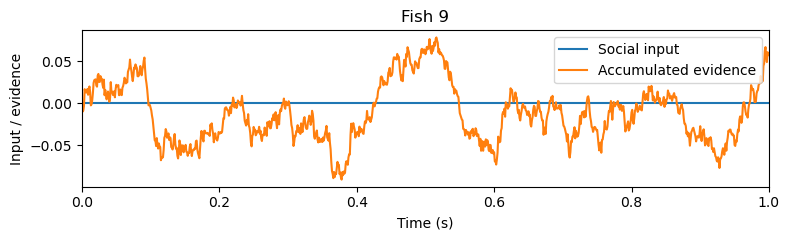

In [95]:
focal_fish = n_fish - 1

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(time, social_input_history[focal_fish], label="Social input")
ax.plot(time, evidence_history[focal_fish], label="Accumulated evidence")
ax.set(xlim=(0, total_time), xlabel="Time (s)", ylabel="Input / evidence")
ax.set_title(f"Fish {focal_fish}")
ax.legend()
fig.tight_layout()
plt.show()

## Evidence over time

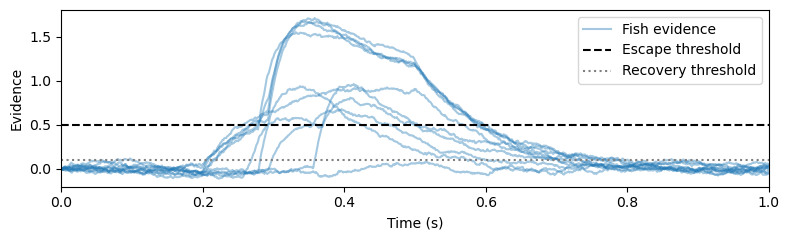

In [96]:
fig, ax = plt.subplots(figsize=(8, 2.5))
lines = ax.plot(time, evidence_history.T, color="tab:blue", alpha=0.4)
lines[0].set_label("Fish evidence")
ax.axhline(threshold, color="black", linestyle="--", label="Escape threshold")
ax.axhline(recovery_threshold, color="grey", linestyle=":",
           label="Recovery threshold")
ax.set(xlim=(0, total_time), xlabel="Time (s)", ylabel="Evidence")
ax.legend()
fig.tight_layout()
plt.show()

## Escape spikes

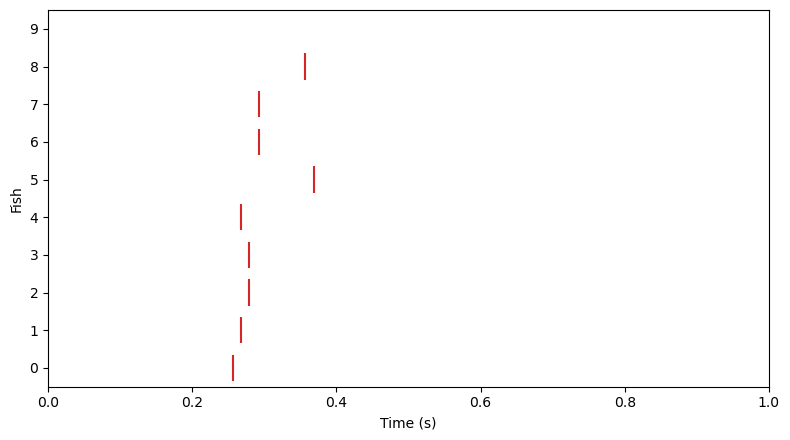

In [97]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for fish_id in range(n_fish):
    escape_times = time[escape_spikes[fish_id] == 1]
    ax.vlines(escape_times, fish_id - 0.35, fish_id + 0.35, color="tab:red")
ax.set(xlim=(0, total_time), ylim=(-0.5, n_fish - 0.5))
ax.set(xlabel="Time (s)", ylabel="Fish", yticks=np.arange(n_fish))
fig.tight_layout()
plt.show()

## Shelter state

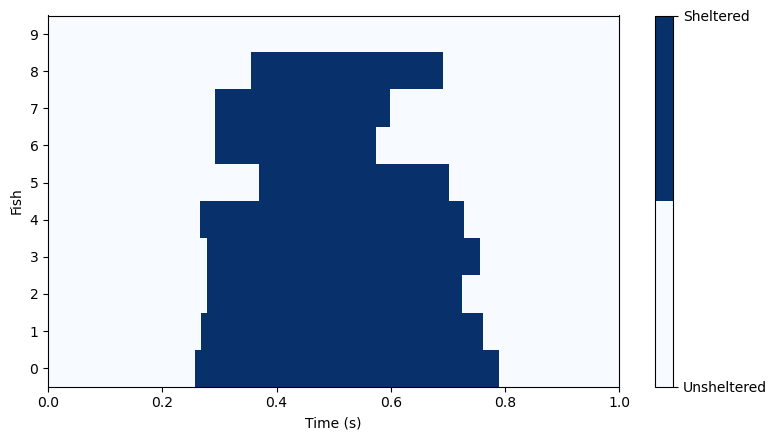

In [98]:
fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(state_history, origin="lower", aspect="auto",
                  extent=(0, total_time, -0.5, n_fish - 0.5),
                  cmap=plt.get_cmap("Blues", 2), vmin=0, vmax=1,
                  interpolation="nearest")
ax.set(xlabel="Time (s)", ylabel="Fish", yticks=np.arange(n_fish))
colorbar = fig.colorbar(image, ax=ax, ticks=[0, 1])
colorbar.ax.set_yticklabels(["Unsheltered", "Sheltered"])
fig.tight_layout()
plt.show()